# BestTime Manhattan Demo

This notebook shows the minimal BestTime workflow for a Manhattan venue. It creates one venue forecast, queries a Manhattan heatmap slice, and prints a compact summary that can be used for validation.

The API key is written directly into the request payload for local smoke testing only. Replace the demo string with a real private key before running against the live API.


In [8]:
import json
from urllib.parse import urlencode
from urllib.error import HTTPError
from urllib.request import Request, urlopen

# BestTime endpoints used by the minimal demo.
BESTTIME_FORECAST_URL = "https://besttime.app/api/v1/forecasts"
BESTTIME_FILTER_URL = "https://besttime.app/api/v1/venues/filter"

# Demo-only plaintext API key. Replace this with a real BestTime private key for live testing.
API_KEY_PRIVATE = "pri_06e221c65c594b168de3ffd8d566a316"

# Manhattan reference point: Mount Sinai Hospital.
VENUE_NAME = "Grand Central Terminal"
VENUE_ADDRESS = "89 E 42nd St, New York, NY 10017"
LAT = 40.7527
LNG = -73.9772
RADIUS = 2500
MANHATTAN_LAT_MIN = 40.700
MANHATTAN_LAT_MAX = 40.882
MANHATTAN_LNG_MIN = -74.030
MANHATTAN_LNG_MAX = -73.910
DAY_INT = 2
HOUR_MIN = 8
HOUR_MAX = 18
# TYPES = "HOSPITAL,PHARMACY,DOCTOR"
TYPES = ""

def post_query_json(url: str, params: dict) -> dict:
    # BestTime's official examples place POST parameters on the URL query string, not in the request body.
    query = urlencode(params)
    request = Request(f"{url}?{query}", method="POST")
    try:
        with urlopen(request, timeout=30) as response:
            return json.loads(response.read().decode("utf-8"))
    except HTTPError as exc:
        error_body = exc.read().decode("utf-8", errors="replace")
        raise RuntimeError(f"BestTime HTTP {exc.code}: {error_body}") from exc

def get_json(url: str, params: dict) -> dict:
    # This is the same pattern as the POST helper, but for a GET request with a query string.
    query = urlencode(params)
    request = Request(f"{url}?{query}", method="GET")
    try:
        with urlopen(request, timeout=30) as response:
            return json.loads(response.read().decode("utf-8"))
    except HTTPError as exc:
        error_body = exc.read().decode("utf-8", errors="replace")
        raise RuntimeError(f"BestTime HTTP {exc.code}: {error_body}") from exc

def create_forecast(api_key_private: str, venue_name: str, venue_address: str) -> dict:
    # Creates or refreshes a forecast for one concrete venue in Manhattan.
    return post_query_json(
        BESTTIME_FORECAST_URL,
        {
            "api_key_private": api_key_private,
            "venue_name": venue_name,
            "venue_address": venue_address,
        },
    )

def filter_manhattan(api_key_private: str, day_int: int, hour_min: int, hour_max: int, types: str = "") -> dict:
    # Uses a bounding box so one request can cover the entire Manhattan island.
    return get_json(
        BESTTIME_FILTER_URL,
        {
            "api_key_private": api_key_private,
            "lat_min": MANHATTAN_LAT_MIN,
            "lat_max": MANHATTAN_LAT_MAX,
            "lng_min": MANHATTAN_LNG_MIN,
            "lng_max": MANHATTAN_LNG_MAX,
            "day_int": day_int,
            "hour_min": hour_min,
            "hour_max": hour_max,
            "types": types,
            "foot_traffic": "both",
            "own_venues_only": False,
            "limit": 1000,
            "page": 0,
        },
    )

def summarize_heatmap(payload: dict) -> list:
    # Normalize the venue list into a compact table for inspection.
    venues = payload.get("venues", [])
    summary = []
    for venue in venues:
        day_raw = venue.get("day_raw_whole") or venue.get("day_raw") or []
        peak = max(day_raw) if day_raw else None
        summary.append({
            "venue_id": venue.get("venue_id"),
            "venue_name": venue.get("venue_name"),
            "lat": venue.get("venue_lat"),
            "lng": venue.get("venue_lng"),
            "peak_busyness": peak,
        })
    return summary


In [9]:
# Step 1: request the Manhattan heatmap slice around the selected area.
# The single-venue forecast is intentionally commented out because BestTime may reject venues that do not have enough traffic history.
# forecast = create_forecast(API_KEY_PRIVATE, VENUE_NAME, VENUE_ADDRESS)
heatmap = filter_manhattan(API_KEY_PRIVATE, DAY_INT, HOUR_MIN, HOUR_MAX, TYPES)

# Step 2: print a compact payload summary that is easy to verify.
result = {
    "region": "Manhattan",
    "query": {
        "lat_min": MANHATTAN_LAT_MIN,
        "lat_max": MANHATTAN_LAT_MAX,
        "lng_min": MANHATTAN_LNG_MIN,
        "lng_max": MANHATTAN_LNG_MAX,
        "day_int": DAY_INT,
        "hour_min": HOUR_MIN,
        "hour_max": HOUR_MAX,
        "types": TYPES,
    },
    "heatmap": {
        "venues_n": heatmap.get("venues_n"),
        "status": heatmap.get("status"),
        "bounding_box": heatmap.get("bounding_box"),
        "top_matches": summarize_heatmap(heatmap)[:10],
    },
}

print(json.dumps(result, indent=2, ensure_ascii=False))


{
  "region": "Manhattan",
  "query": {
    "lat": 40.7527,
    "lng": -73.9772,
    "radius": 2500,
    "day_int": 2,
    "hour_min": 8,
    "hour_max": 18,
    "types": ""
  },
  "heatmap": {
    "venues_n": 20,
    "status": "OK",
    "bounding_box": null,
    "top_matches": [
      {
        "venue_id": "ven_5556474f56636f7565674c526b6f7759566c78494a516d4a496843",
        "venue_name": "Times Square",
        "lat": 40.7579747,
        "lng": -73.9855426,
        "peak_busyness": 65
      },
      {
        "venue_id": "ven_4d6a306b416131617a736f526b6f7759355f7a6d3155394a496843",
        "venue_name": "Rockefeller Center",
        "lat": 40.7587402,
        "lng": -73.9786736,
        "peak_busyness": 95
      },
      {
        "venue_id": "ven_514c6e7669624a33455f70526b6f775a703635674762764a496843",
        "venue_name": "Bryant Park",
        "lat": 40.7535367,
        "lng": -73.9829529,
        "peak_busyness": 95
      },
      {
        "venue_id": "ven_6f394669377a4466594d4

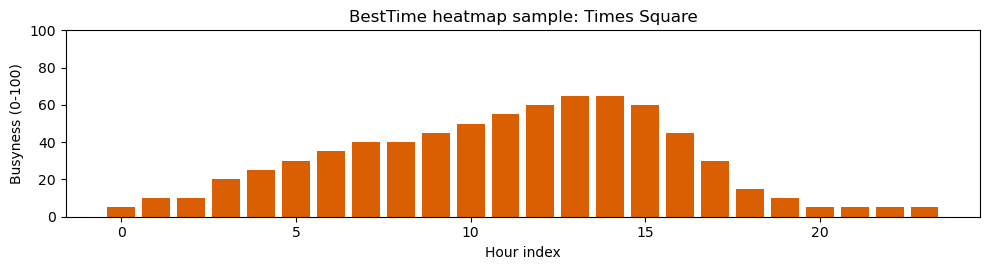

In [10]:
# Optional visualization: render the first heatmap venue curve as a simple bar chart if matplotlib is available.
try:
    import matplotlib.pyplot as plt

    first_venue = (heatmap.get("venues") or [{}])[0]
    day_raw = first_venue.get("day_raw_whole") or first_venue.get("day_raw") or []
    if day_raw:
        hours = list(range(len(day_raw)))
        plt.figure(figsize=(10, 2.8))
        plt.bar(hours, day_raw, color="#d95f02")
        plt.ylim(0, 100)
        plt.xlabel("Hour index")
        plt.ylabel("Busyness (0-100)")
        plt.title(f"BestTime heatmap sample: {first_venue.get('venue_name', 'Unknown venue')}")
        plt.tight_layout()
        plt.show()
    else:
        print("No day_raw_whole/day_raw values returned for the first venue.")
except ImportError:
    print("matplotlib is not installed, so the notebook only prints the JSON summary.")


## Manhattan 1 km Scenario Matrix

The next section queries the same Manhattan center point with a fixed 1 km radius and compares several time windows side by side. This is a practical way to read the BestTime output as a scenario matrix instead of a single static map.


## Folium Manhattan Map

This version uses Leaflet through Folium, draws venue points on top of a real map, and colors each point by peak busyness. Each scenario is added as a separate overlay layer so you can compare the same Manhattan area under different time windows.


In [13]:
import folium
from branca.colormap import linear

# Four time windows as separate layers on one map.
FOLIUM_SCENARIOS = [
    {"label": "Mon 08-12", "day_int": 0, "hour_min": 8, "hour_max": 12},
    {"label": "Mon 12-18", "day_int": 0, "hour_min": 12, "hour_max": 18},
    {"label": "Wed 08-12", "day_int": 2, "hour_min": 8, "hour_max": 12},
    {"label": "Wed 12-18", "day_int": 2, "hour_min": 12, "hour_max": 18},
]

# BestTime heatmaps are relative scores, so a 0-100 color scale is enough.
colormap = linear.YlOrRd_09.scale(0, 100)
colormap.caption = "Peak busyness (0-100)"


def fetch_heatmap_for_scenario(day_int: int, hour_min: int, hour_max: int) -> dict:
    # Use Manhattan bounding box so each scenario covers the whole island with one request.
    return filter_manhattan(
        API_KEY_PRIVATE,
        day_int,
        hour_min,
        hour_max,
        TYPES,
    )


def add_scenario_layer(map_obj, scenario: dict):
    # If the filter is too restrictive, BestTime can return no venues. That is handled by the fallback note in the layer.
    payload = fetch_heatmap_for_scenario(scenario["day_int"], scenario["hour_min"], scenario["hour_max"])
    layer = folium.FeatureGroup(name=scenario["label"], show=True)
    points = venue_points(payload)

    if not points:
        folium.Marker(
            location=[(MANHATTAN_LAT_MIN + MANHATTAN_LAT_MAX) / 2, (MANHATTAN_LNG_MIN + MANHATTAN_LNG_MAX) / 2],
            popup=f"{scenario['label']}: no venues returned",
            icon=folium.Icon(color="gray", icon="info-sign"),
        ).add_to(layer)
        layer.add_to(map_obj)
        return payload

    for point in points:
        color = colormap(point["peak"] or 0)
        popup_html = f"""
        <b>{point['name']}</b><br>
        Peak busyness: {point['peak']}<br>
        Lat/Lng: {point['lat']}, {point['lng']}
        """
        folium.CircleMarker(
            location=[point["lat"], point["lng"]],
            radius=8,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.9,
            weight=1,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f"{point['name']} | peak {point['peak']}",
        ).add_to(layer)

    layer.add_to(map_obj)
    return payload


# Create one map centered on Manhattan and add each scenario as a toggleable layer.
map_center = folium.Map(
    location=[(MANHATTAN_LAT_MIN + MANHATTAN_LAT_MAX) / 2, (MANHATTAN_LNG_MIN + MANHATTAN_LNG_MAX) / 2],
    zoom_start=12,
    tiles="CartoDB positron",
    width="100%",
    height="720px",
)
folium.Rectangle(
    bounds=[[MANHATTAN_LAT_MIN, MANHATTAN_LNG_MIN], [MANHATTAN_LAT_MAX, MANHATTAN_LNG_MAX]],
    color="#3186cc",
    fill=False,
    weight=2,
    tooltip="Manhattan analysis bounding box",
).add_to(map_center)

scenario_payloads = {}
for scenario in FOLIUM_SCENARIOS:
    scenario_payloads[scenario["label"]] = add_scenario_layer(map_center, scenario)

# Fit the map to the Manhattan bounds so the tile layer fills the viewport.
map_center.fit_bounds([[MANHATTAN_LAT_MIN, MANHATTAN_LNG_MIN], [MANHATTAN_LAT_MAX, MANHATTAN_LNG_MAX]])

colormap.add_to(map_center)
folium.LayerControl(collapsed=False).add_to(map_center)
map_center
